### Utilizando CNN pré treinada (ResNet50) para reconhecimento

In [ ]:
# Ative a VENV no terminal

python -m venv venv
".venv\Scripts\activate.ps1"

In [ ]:
# Instalação das dependências
!pip install ipykernel

!pip install tensorflow matplotlib numpy tqdm --progress-bar on

# gera requirements
!pip freeze > requirements.txt

!pip install -r requirements.txt


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# importação das bibliotecas

from tensorflow import keras
from keras import applications, preprocessing
import numpy as np 
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import time



Utilização de uma Rede Neural Convolucional (CNN) já treinada previamente (ResNet50) em um dataset gigante chamado ImageNet só para inferência/classificação.

A ResNet já foi treinada pela equipe da Microsoft Research com milhões de imagens e milhões de categorias.

quando usamos `weights='imagenet'` já estamos baixando pesos prontos.

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted:
1. monarch: (98.79%)
2. ringlet: (0.51%)
3. sulphur_butterfly: (0.21%)


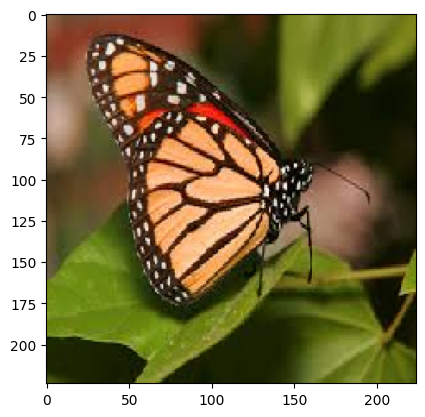

In [7]:
model = applications.ResNet50(weights='imagenet')
img_path = 'imagens_teste/image1.png'
img = preprocessing.image.load_img(img_path, target_size=(224, 224))
x = preprocessing.image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = applications.resnet50.preprocess_input(x)
preds = model.predict(x)
decoded_preds = applications.resnet50.decode_predictions(preds, top=3)[0]
plt.imshow(img)

print('Predicted:')
for i, (imagenet_id, label, score) in enumerate(decoded_preds):
    print(f"{i+1}. {label}: ({score*100:.2f}%)")